In [1]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings()

In [2]:
#read in raw bin1 and bin50 data for human embryo

adata_bin1 = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_bin1.h5ad")
adata_bin50 = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_bin50.h5ad")

print(adata_bin1.shape)
print(adata_bin50.shape)

(508126689, 49848)
(662769, 49848)


In [3]:
#filtering for bin1 data

sc.pp.filter_cells(adata_bin1, min_counts=1)
sc.pp.filter_genes(adata_bin1, min_counts=100)
sc.pp.filter_genes(adata_bin1, min_cells=10)

#filtering for bin50 data

sc.pp.filter_genes(adata_bin50, min_cells=50)

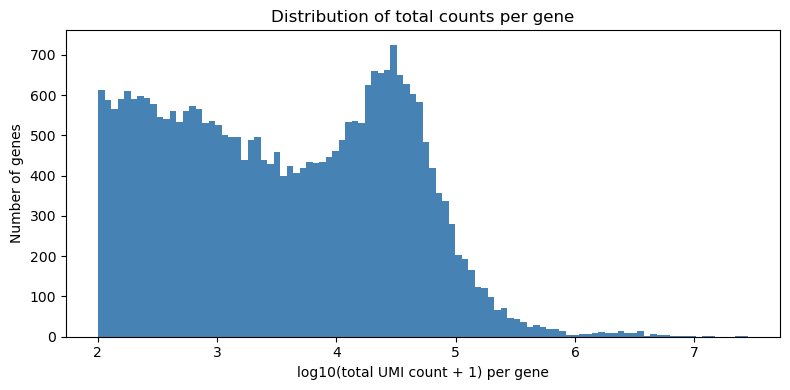

In [7]:
gene_totals = np.asarray(adata_bin1.X.sum(axis=0)).flatten()  # sum across all spots for each gene
log_totals = np.log10(gene_totals + 1)

plt.figure(figsize=(8, 4))
plt.hist(log_totals, bins=100, color='steelblue', edgecolor='none')
plt.xlabel("log10(total UMI count + 1) per gene")
plt.ylabel("Number of genes")
plt.title("Distribution of total counts per gene")
plt.tight_layout()
plt.show()

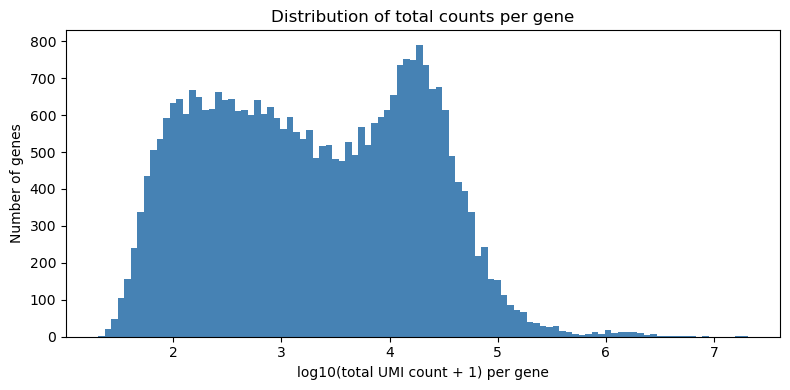

In [9]:
gene_totals = np.asarray(np.expm1(adata_bin50.X).sum(axis=0)).flatten()  # sum across all spots for each gene
log_totals = np.log10(gene_totals + 1)

plt.figure(figsize=(8, 4))
plt.hist(log_totals, bins=100, color='steelblue', edgecolor='none')
plt.xlabel("log10(total UMI count + 1) per gene")
plt.ylabel("Number of genes")
plt.title("Distribution of total counts per gene")
plt.tight_layout()
plt.show()

In [10]:
#read in raw data for mouse embryo

adata_mouse = ad.read_h5ad("../data/mouse_E16.5_E1S1_raw_dnb.h5ad")

In [13]:
#filtering for mouse data

sc.pp.filter_cells(adata_mouse, min_counts=1)
sc.pp.filter_genes(adata_mouse, min_counts=100)
sc.pp.filter_genes(adata_mouse, min_cells=10)

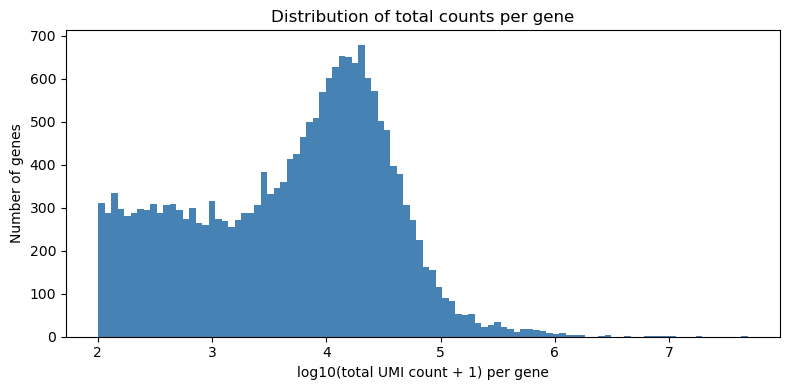

In [14]:
gene_totals = np.asarray(adata_mouse.X.sum(axis=0)).flatten()  # sum across all spots for each gene
log_totals = np.log10(gene_totals + 1)

plt.figure(figsize=(8, 4))
plt.hist(log_totals, bins=100, color='steelblue', edgecolor='none')
plt.xlabel("log10(total UMI count + 1) per gene")
plt.ylabel("Number of genes")
plt.title("Distribution of total counts per gene")
plt.tight_layout()
plt.show()

In [ ]:

# UMIs per bin: mouse vs human bin1 (raw counts, after cell/gene filtering)
import numpy as np
import scipy.sparse as sp

human_row_sums = np.asarray(adata_bin1.X.sum(axis=1)).flatten()
mouse_row_sums = np.asarray(adata_mouse.X.sum(axis=1)).flatten()

# clip at 99th percentile so outliers don't compress the histogram
clip_val = max(np.percentile(human_row_sums, 99), np.percentile(mouse_row_sums, 99))
human_clipped = np.clip(human_row_sums, 0, clip_val)
mouse_clipped  = np.clip(mouse_row_sums,  0, clip_val)

bins = np.linspace(0, clip_val, 150)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, label, color in zip(
    axes,
    [mouse_clipped, human_clipped],
    ['Mouse E16.5 (bin1)', 'Human CS23 (bin1)'],
    ['steelblue', 'darkorange']
):
    ax.hist(data, bins=bins, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(np.mean(data), color='black', linewidth=1.5, linestyle='--', label=f'Mean: {np.mean(data):.2f}')
    ax.axvline(np.median(data), color='black', linewidth=1.5, linestyle=':', label=f'Median: {np.median(data):.2f}')
    ax.set_title(label)
    ax.set_xlabel('Total UMIs per bin (clipped at 99th pct)')
    ax.set_ylabel('Number of bins')
    ax.legend(fontsize=9)

plt.suptitle('UMI count distribution per bin (raw counts)', y=1.02)
plt.tight_layout()
plt.show()

print(f"Mouse  — mean: {np.mean(mouse_row_sums):.3f}, median: {np.median(mouse_row_sums):.1f}, "
      f"n bins: {len(mouse_row_sums):,}")
print(f"Human  — mean: {np.mean(human_row_sums):.3f}, median: {np.median(human_row_sums):.1f}, "
      f"n bins: {len(human_row_sums):,}")
